## Getting the data

Request all issues with personified token from github_apikey.key file. One can generate a token under https://github.com/settings/tokens

Downloaded data available on https://gigamove.rwth-aachen.de/de/download/5726f0a388b74818ddd8fdec187bd267

In [1]:
import requests
import time
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import nltk
from nltk.tokenize import word_tokenize
import re
import ast
import random
import statistics
import math
from pathlib import Path
from typing import List, Dict, Optional
from collections import Counter, defaultdict

In [ ]:
TOKEN = "YOUR_PERSONAL_ACCESS_TOKEN" 
if os.path.exists("github_apikey.key"):
    with open("github_apikey.key", 'r') as f:
        TOKEN = f.read().replace("\n", "")

query_template = """
query($cursor: String) {
  rateLimit {
    cost
    remaining
    resetAt
  }
  repository(owner: "%s", name: "%s") {
    issues(
      states: CLOSED, 
      first: 30, 
      after: $cursor
    ) {
      pageInfo {
        hasNextPage
        endCursor
      }
      nodes {
        number
        title
        body
        createdAt
        author {
          login
        }
        labels(first: 20) {
          nodes {
            name
          }
        }
        comments(first: 100) {
          nodes {
            author {
              login
            }
            body
          }
        }
      }
    }
  }
}
"""


In [ ]:
def run_query(owner, repo, cursor):
    url = 'https://api.github.com/graphql'
    headers = {"Authorization": f"Bearer {TOKEN}"}
    variables = {"cursor": cursor}
    
    try:
        response = requests.post(url, json={'query': query_template % (owner, repo), 'variables': variables}, headers=headers, timeout=30)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

In [ ]:
def request_all_issues(owner, repo):
    has_next = True
    cursor = None
    total_issues_processed = 0

    raw_data = open("raw_data_"+repo+".txt", 'w', encoding='utf-8')

    while has_next:
        result = run_query(owner, repo, cursor)
        
        # Check for empty result or connection failure
        if not result:
            print("Network error. Sleeping 5s...")
            time.sleep(5)
            continue

        # Check for GraphQL specific errors (e.g., Bad syntax)
        if 'errors' in result:
            print(f"GraphQL Error: {result['errors']}")
            break # Break loop, otherwise it retries infinitely

        # Check if data exists
        if 'data' not in result or not result['data']:
            print("No data returned.")
            break
        
        data = result['data']
        
        if 'rateLimit' in data:
            rate_limit = data['rateLimit']
            remaining = rate_limit['remaining']
            print(f"Points remaining: {remaining} (Cost: {rate_limit['cost']})")
            
            if remaining < 100:
                print("RATE LIMIT NEAR! Sleeping for 1 hour...")
                time.sleep(3600)
        
        data_repo = data['repository']['issues']
        
        for issue in data_repo['nodes']:
            if not issue or not issue['author'] or not issue['title'] or not issue['body']: 
                continue
            
            issue_id = str(issue['number'])
            issue_author = issue['author']['login']

            issue_title = issue['title'].replace("\n", " ").replace("\r", "")
            issue_body = issue['body'].replace("\n", " ").replace("\r", "")
            issue_date = issue['createdAt']

            label_list = []
            if 'labels' in issue and issue['labels']['nodes']:
                label_list = [l['name'] for l in issue['labels']['nodes']]
            
            label_str = "|".join(label_list)

            raw_data.write(f"issue:{issue_author}\n{label_str}\n{issue_date}\n{issue_title}\n{issue_body}\n")

            if 'comments' in issue and issue['comments']['nodes']:
                for comment in issue['comments']['nodes']:
                    if not comment or not comment['author'] or not comment['body']: 
                        continue
                    
                    comment_author = comment['author']['login']
                    
                    comment_body = comment['body'].replace("\n", " ").replace("\r", "")

                    raw_data.write(f"comment:{comment_author}\n{comment_body}\n")

        # Update Progress
        total_issues_processed += len(data_repo['nodes'])
        has_next = data_repo['pageInfo']['hasNextPage']
        cursor = data_repo['pageInfo']['endCursor']
        
        print(f"Total issues saved: {total_issues_processed}")

    raw_data.close()
    print("Done")

In [ ]:
#request_all_issues("tensorflow", "tensorflow")

In [ ]:
#request_all_issues("networkx", "networkx")

In [ ]:
#request_all_issues("pandas-dev", "pandas")

## Building the graph

In [2]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

G_tensorflow = nx.DiGraph()

current_issue_opener = ""

for line in read_raw_data:
    if line.startswith("issue:"):
        current_issue_opener = line.strip().split(':')[1]
    elif line.startswith("comment:"):
        commentor = line.strip().split(':')[1]
        if commentor != current_issue_opener: 
            G_tensorflow.add_edge(commentor, current_issue_opener)

read_raw_data.close()
print(G_tensorflow)

DiGraph with 42897 nodes and 112810 edges


In [3]:
read_raw_data = open("raw_data_pandas.txt", 'r', encoding='utf-8')

G_pandas = nx.DiGraph()

current_issue_opener = ""

for line in read_raw_data:
    if line.startswith("issue:"):
        current_issue_opener = line.strip().split(':')[1]
    elif line.startswith("comment:"):
        commentor = line.strip().split(':')[1]
        if commentor != current_issue_opener: 
            G_pandas.add_edge(commentor, current_issue_opener)

read_raw_data.close()
print(G_pandas)

DiGraph with 14738 nodes and 31709 edges


In [4]:
read_raw_data = open("raw_data_networkx.txt", 'r', encoding='utf-8')

G_networkx = nx.DiGraph()

current_issue_opener = ""

for line in read_raw_data:
    if line.startswith("issue:"):
        current_issue_opener = line.strip().split(':')[1]
    elif line.startswith("comment:"):
        commentor = line.strip().split(':')[1]
        if commentor != current_issue_opener: 
            G_networkx.add_edge(commentor, current_issue_opener)

read_raw_data.close()
print(G_networkx)

DiGraph with 1696 nodes and 2858 edges


In [5]:
largest = max(nx.weakly_connected_components(G_tensorflow), key=len)
G_tensorflow = G_tensorflow.subgraph(largest)

largest = max(nx.weakly_connected_components(G_pandas), key=len)
G_pandas = G_pandas.subgraph(largest)

largest = max(nx.weakly_connected_components(G_networkx), key=len)
G_networkx = G_networkx.subgraph(largest)

print("G is a " + str(G_tensorflow))
print("G is a " + str(G_pandas))
print("G is a " + str(G_networkx))

G is a DiGraph with 42785 nodes and 112749 edges
G is a DiGraph with 14648 nodes and 31662 edges
G is a DiGraph with 1680 nodes and 2850 edges


In [6]:
both_tensorflow_pandas = [d for d in G_tensorflow.nodes() if d in G_pandas]
both_tensorflow_networkx = [d for d in G_tensorflow.nodes() if d in G_networkx]
both_pandas_networkx = [d for d in G_pandas.nodes() if d in G_networkx]

print(len(both_tensorflow_pandas), len(both_tensorflow_networkx), len(both_pandas_networkx))

1028 121 205


In [7]:
in_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_pandas = sorted([d for d in G_pandas.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_pandas = sorted([d for d in G_pandas.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_networkx = sorted([d for d in G_networkx.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_networkx = sorted([d for d in G_networkx.out_degree()], key=lambda x: x[1], reverse=True)

df_top10_in_tensorflow = pd.DataFrame(in_degree_sequence_tensorflow[0:10], columns=('User', ''))
df_top10_out_tensorflow = pd.DataFrame(out_degree_sequence_tensorflow[0:10], columns=('User', ''))

df_top10_in_pandas = pd.DataFrame(in_degree_sequence_pandas[0:10], columns=('User', ''))
df_top10_out_pandas = pd.DataFrame(out_degree_sequence_pandas[0:10], columns=('User', ''))

df_top10_in_networkx = pd.DataFrame(in_degree_sequence_networkx[0:10], columns=('User', ''))
df_top10_out_networkx = pd.DataFrame(out_degree_sequence_networkx[0:10], columns=('User', ''))

frames = {
    ('TensorFlow', 'In-Degree'): df_top10_in_tensorflow,
    ('TensorFlow', 'Out-Degree'): df_top10_out_tensorflow,
    ('Pandas', 'In-Degree'): df_top10_in_pandas,
    ('Pandas', 'Out-Degree'): df_top10_out_pandas,
    ('NetworkX', 'In-Degree'): df_top10_in_networkx,
    ('NetworkX', 'Out-Degree'): df_top10_out_networkx,
}

combined_df = pd.concat(
    [df.reset_index(drop=True) for df in frames.values()], 
    axis=1, 
    keys=frames.keys()
)

print(combined_df.to_string(index=False))

     TensorFlow                                       Pandas                                  NetworkX                      
      In-Degree           Out-Degree               In-Degree             Out-Degree          In-Degree        Out-Degree    
           User                 User                    User                   User               User              User    
     yaroslavvb 222 google-ml-butler 9979            jreback 568            jreback 3534       dschult 49        dschult 838
      cancan101 189 tensorflowbutler 3513 jorisvandenbossche 345          mroeschke 1983       rossbar 46        hagberg 320
       ppwwyyxx 174   github-actions 2662      TomAugspurger 334      TomAugspurger 1835       MridulS 45        rossbar 316
     alanpurple 146       tilakrayal 2123       MarcoGorelli 291 jorisvandenbossche 1415 networkx-trac 36        MridulS 194
dynamicwebpaige 137           ymodak 2100     datapythonista 265         rhshadrach 1062 jarrodmillman 33       chebee7i  81


In [8]:
print(f"The median of the in degree is {in_degree_sequence_tensorflow[int(len(in_degree_sequence_tensorflow)/2)][1]} and also for the out degree it is {out_degree_sequence_tensorflow[int(len(out_degree_sequence_tensorflow)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_tensorflow])/len(in_degree_sequence_tensorflow):.4f}.")

The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.6352.


In [9]:
print(f"The median of the in degree is {in_degree_sequence_pandas[int(len(in_degree_sequence_pandas)/2)][1]} and also for the out degree it is {out_degree_sequence_pandas[int(len(out_degree_sequence_pandas)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_pandas])/len(in_degree_sequence_pandas):.4f}.")

The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.1615.


In [10]:
print(f"The median of the in degree is {in_degree_sequence_networkx[int(len(in_degree_sequence_networkx)/2)][1]} and also for the out degree it is {out_degree_sequence_networkx[int(len(out_degree_sequence_networkx)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_networkx])/len(in_degree_sequence_networkx):.4f}.")

The median of the in degree is 1 and also for the out degree it is 0.
The average degree is 1.6964.


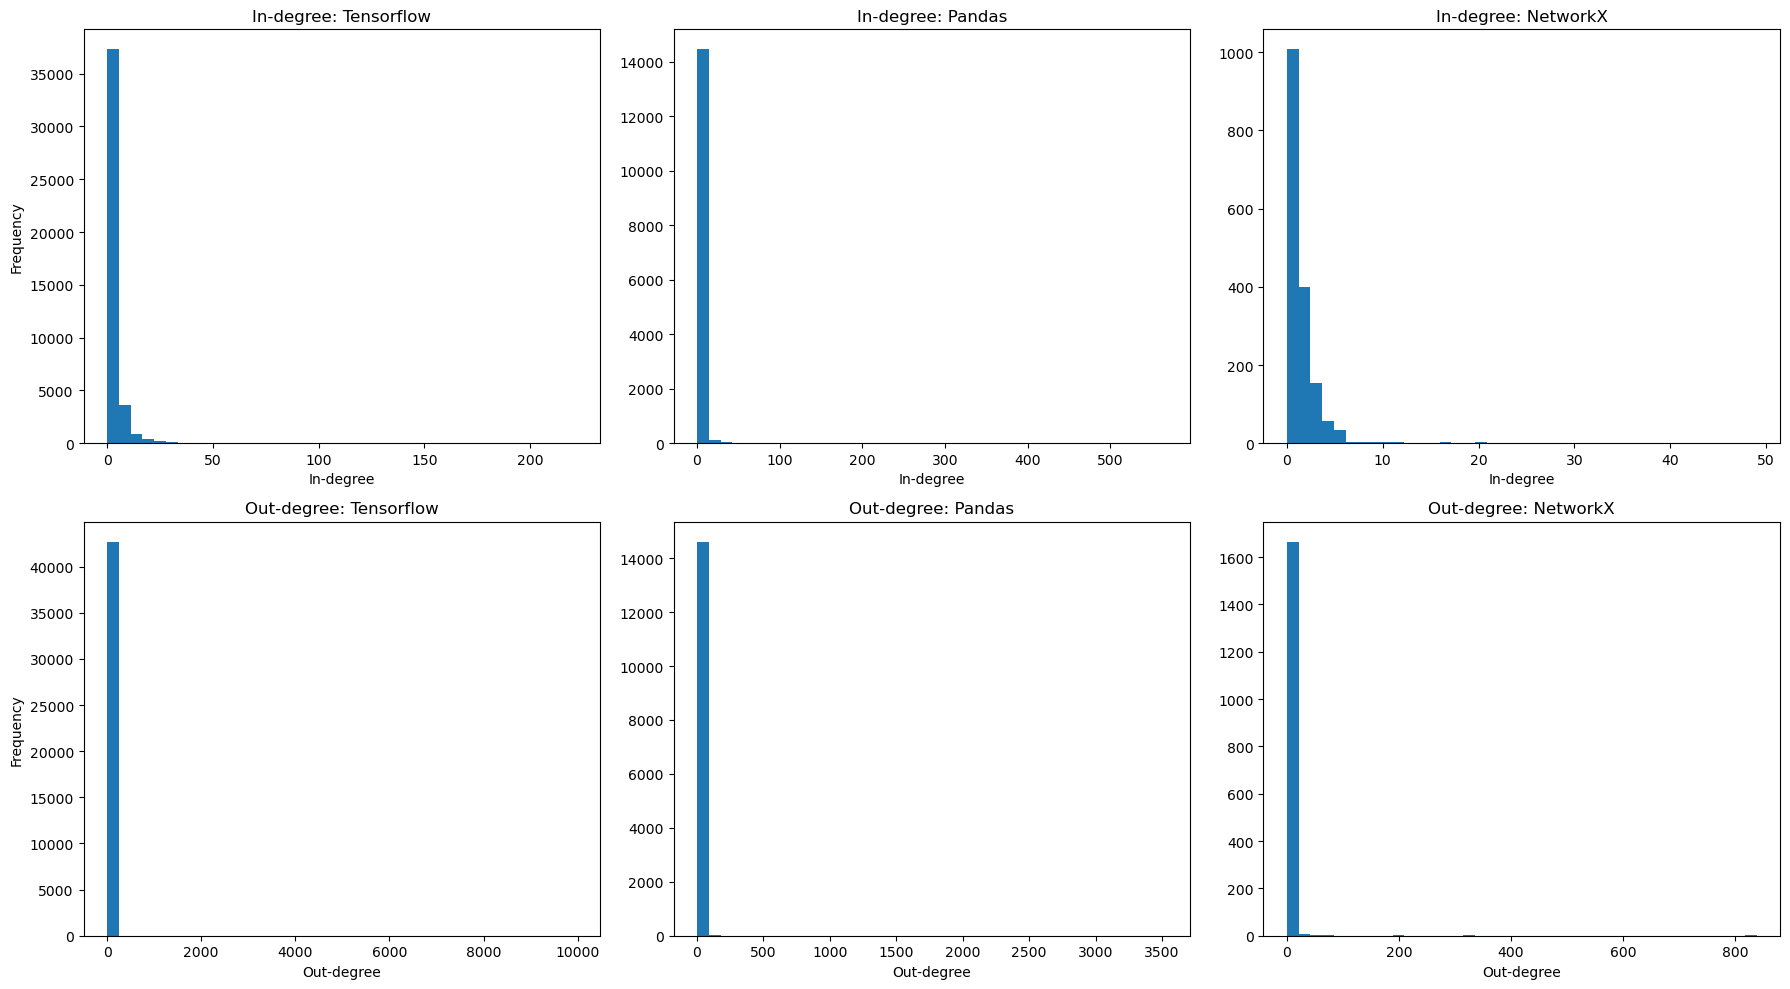

In [11]:
number_bins = 40

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_degree_sequence_tensorflow], bins=number_bins)
axes[0, 0].set_title("In-degree: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_degree_sequence_pandas], bins=number_bins)
axes[0, 1].set_title("In-degree: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_degree_sequence_networkx], bins=number_bins)
axes[0, 2].set_title("In-degree: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_degree_sequence_tensorflow], bins=number_bins)
axes[1, 0].set_title("Out-degree: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_degree_sequence_pandas], bins=number_bins)
axes[1, 1].set_title("Out-degree: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_degree_sequence_networkx], bins=number_bins)
axes[1, 2].set_title("Out-degree: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

In [12]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in in_degree_sequence_tensorflow if x[1]<=1])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The number of nodes that have an out degree of 1 is {len([x for x in out_degree_sequence_tensorflow if x[1]<=1])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 56.75%.
The number of nodes that have an out degree of 1 is 85.03%.


In [13]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in in_degree_sequence_pandas if x[1]<=1])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The number of nodes that have an out degree of 1 is {len([x for x in out_degree_sequence_pandas if x[1]<=1])/len(out_degree_sequence_pandas)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 59.45%.
The number of nodes that have an out degree of 1 is 87.54%.


In [14]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in in_degree_sequence_networkx if x[1]<=1])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The number of nodes that have an out degree of 1 is {len([x for x in out_degree_sequence_networkx if x[1]<=1])/len(out_degree_sequence_networkx)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 60.00%.
The number of nodes that have an out degree of 1 is 92.80%.


In [48]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in G_networkx.degree() if x[1] == 1])/len(in_degree_sequence_networkx)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 54.23%.


In [50]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in G_tensorflow.degree() if x[1] == 1])/len(in_degree_sequence_tensorflow)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 47.20%.


In [51]:
print(f"The number of nodes that have an in degree of 1 is {len([x for x in G_pandas.degree() if x[1] == 1])/len(in_degree_sequence_pandas)*100:.2f}%.")

The number of nodes that have an in degree of 1 is 49.92%.


In [15]:
cutoff = 10

print(f"The number of nodes that have an in degree of less than {cutoff} is {len([x for x in in_degree_sequence_tensorflow if x[1]<cutoff])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The number of nodes that have an out degree of less than {cutoff} is {len([x for x in out_degree_sequence_tensorflow if x[1]<cutoff])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

The number of nodes that have an in degree of less than 10 is 94.21%.
The number of nodes that have an out degree of less than 10 is 98.84%.


In [16]:
print(f"The number of nodes that have an in degree of less than {cutoff} is {len([x for x in in_degree_sequence_pandas if x[1]<cutoff])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The number of nodes that have an out degree of less than {cutoff} is {len([x for x in out_degree_sequence_pandas if x[1]<cutoff])/len(out_degree_sequence_pandas)*100:.2f}%.")

The number of nodes that have an in degree of less than 10 is 97.03%.
The number of nodes that have an out degree of less than 10 is 98.94%.


In [17]:
print(f"The number of nodes that have an in degree of less than {cutoff} is {len([x for x in in_degree_sequence_networkx if x[1]<cutoff])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The number of nodes that have an out degree of less than {cutoff} is {len([x for x in out_degree_sequence_networkx if x[1]<cutoff])/len(out_degree_sequence_networkx)*100:.2f}%.")

The number of nodes that have an in degree of less than 10 is 98.81%.
The number of nodes that have an out degree of less than 10 is 98.87%.


In [18]:
in_tensorflow_greater_cutoff = [d for d in G_tensorflow.in_degree() if d[1] >= cutoff]
out_tensorflow_greater_cutoff = [d for d in G_tensorflow.out_degree() if d[1] >= cutoff]

in_pandas_greater_cutoff = [d for d in G_pandas.in_degree() if d[1] >= cutoff]
out_pandas_greater_cutoff = [d for d in G_pandas.out_degree() if d[1] >= cutoff]

in_networkx_greater_cutoff = [d for d in G_networkx.in_degree() if d[1] >= cutoff]
out_networkx_greater_cutoff = [d for d in G_networkx.out_degree() if d[1] >= cutoff]

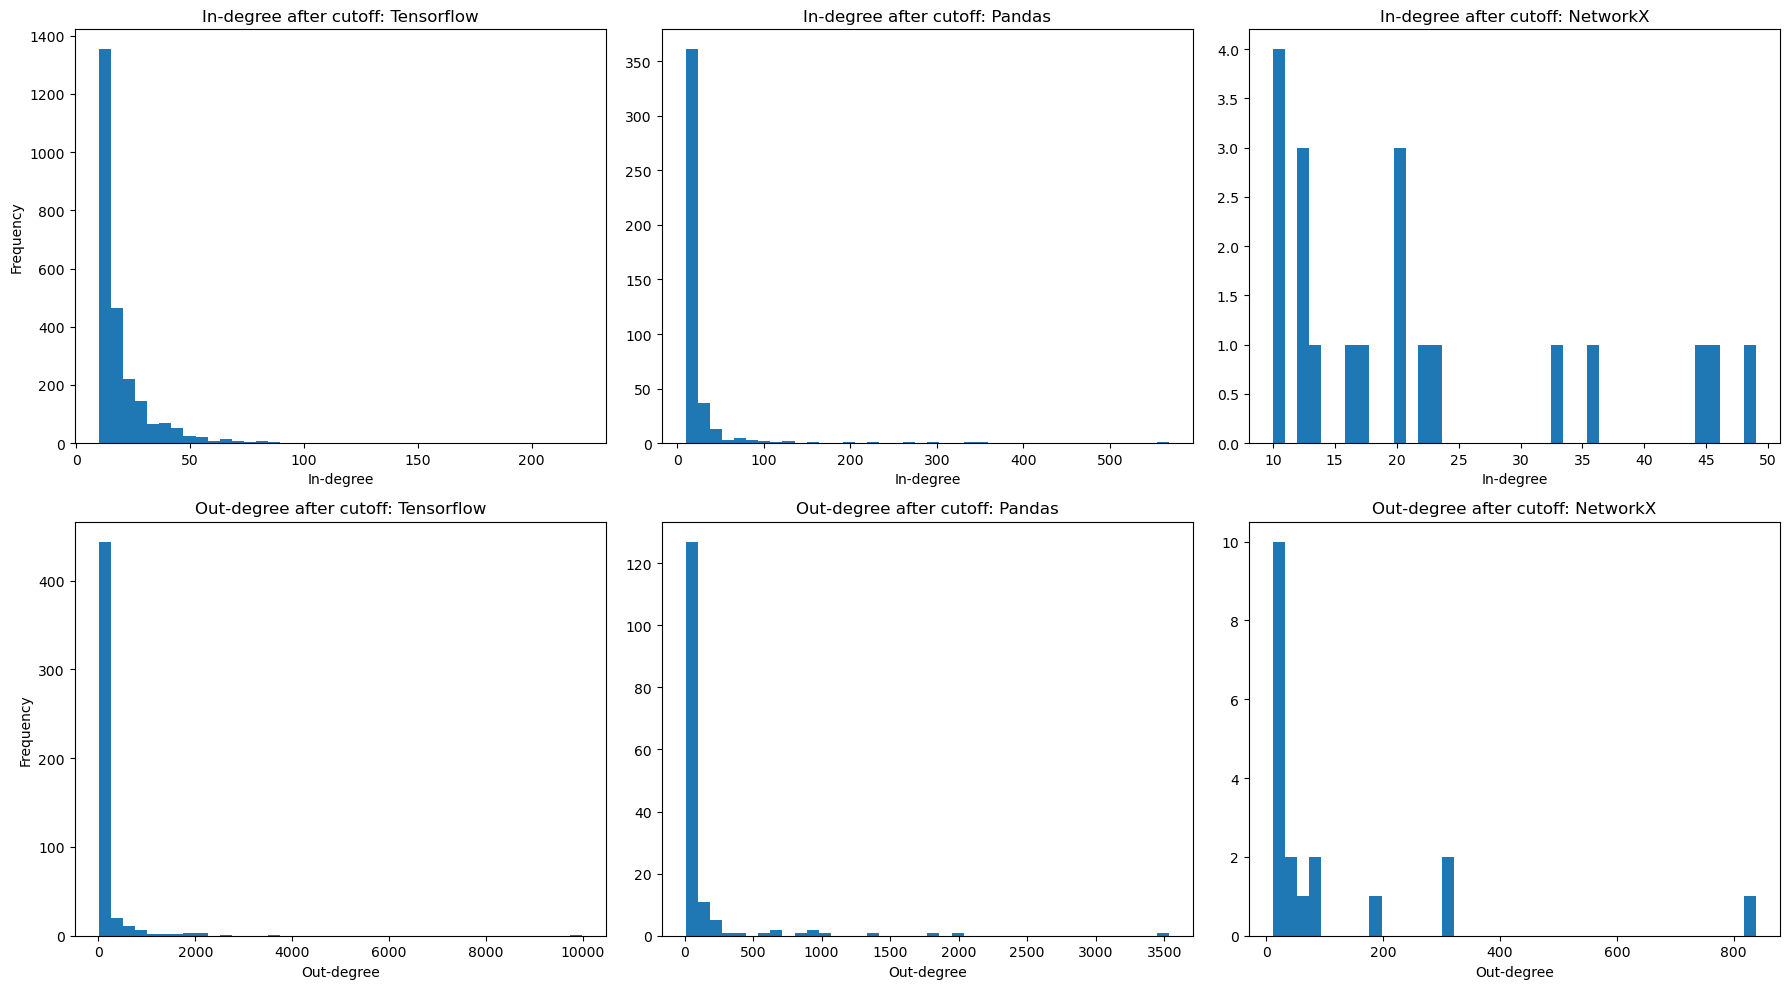

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_tensorflow_greater_cutoff], bins=number_bins)
axes[0, 0].set_title("In-degree after cutoff: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_pandas_greater_cutoff], bins=number_bins)
axes[0, 1].set_title("In-degree after cutoff: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_networkx_greater_cutoff], bins=number_bins)
axes[0, 2].set_title("In-degree after cutoff: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_tensorflow_greater_cutoff], bins=number_bins)
axes[1, 0].set_title("Out-degree after cutoff: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_pandas_greater_cutoff], bins=number_bins)
axes[1, 1].set_title("Out-degree after cutoff: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_networkx_greater_cutoff], bins=number_bins)
axes[1, 2].set_title("Out-degree after cutoff: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

In [20]:
# print(nx.average_shortest_path_length(G_tensorflow.to_undirected()))
# print(nx.average_shortest_path_length(G_pandas.to_undirected()))
# print(nx.average_shortest_path_length(G_networkx.to_undirected()))

In [21]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

path = "top10-tensorflow/"

for (user, _) in in_degree_sequence_tensorflow[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_tensorflow[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()
    

In [23]:
read_raw_data = open("raw_data_pandas.txt", 'r', encoding='utf-8')

path_pandas = "top10-pandas/"

for (user, _) in in_degree_sequence_pandas[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path_pandas + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_pandas[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path_pandas + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()

In [25]:
read_raw_data = open("raw_data_networkx.txt", 'r', encoding='utf-8')

path_networkx = "top10-networkx/"

for (user, _) in in_degree_sequence_networkx[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path_networkx + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_networkx[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path_networkx + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()
    

In [28]:
def text_without_stopwords(text):
    stopwords = nltk.corpus.stopwords.words('english')
    return [w.lower() for w in text if w.lower() not in stopwords and w.isalpha()]
     
files = os.listdir(path)

for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())
        print(nltk.FreqDist(text_without_stopwords(tokens)).most_common(50))

[('tensorflow', 245), ('file', 183), ('line', 162), ('std', 159), ('https', 124), ('optimized', 118), ('char', 106), ('const', 80), ('import', 78), ('error', 73), ('tf', 58), ('python', 57), ('eigen', 51), ('module', 50), ('run', 43), ('build', 43), ('version', 43), ('op', 41), ('use', 39), ('long', 37), ('tensor', 35), ('fails', 35), ('cuda', 35), ('float', 34), ('like', 33), ('graph', 33), ('call', 32), ('return', 31), ('last', 31), ('support', 31), ('gpu', 31), ('sess', 28), ('could', 27), ('following', 27), ('ops', 27), ('device', 26), ('memory', 26), ('recent', 25), ('type', 25), ('would', 25), ('library', 24), ('x', 24), ('failed', 23), ('default', 23), ('namespace', 23), ('node', 22), ('print', 22), ('traceback', 21), ('variable', 21), ('output', 20)]
[('https', 116), ('tensorflow', 42), ('using', 41), ('image', 38), ('cuda', 37), ('gpu', 31), ('see', 30), ('build', 30), ('root', 30), ('op', 30), ('use', 28), ('tf', 24), ('graph', 24), ('library', 22), ('name', 22), ('model', 22

In [ ]:
for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())

        text1_without = text_without_stopwords(tokens)

        all_bigrams = list(nltk.bigrams(text1_without))
            
        fdist_bigrams = nltk.FreqDist(all_bigrams)

        print(fdist_bigrams.most_common(50))

[(('file', 'line'), 145), (('optimized', 'optimized'), 110), (('std', 'char'), 93), (('char', 'std'), 73), (('tensorflow', 'tensorflow'), 46), (('line', 'module'), 44), (('std', 'std'), 33), (('module', 'import'), 30), (('const', 'tensorflow'), 30), (('import', 'tensorflow'), 26), (('tensorflow', 'const'), 24), (('tensorflow', 'std'), 23), (('tensorflow', 'tf'), 21), (('recent', 'call'), 21), (('call', 'last'), 21), (('long', 'long'), 21), (('traceback', 'recent'), 20), (('last', 'file'), 20), (('line', 'file'), 19), (('char', 'const'), 17), (('eigen', 'float'), 17), (('tensorflow', 'anonymous'), 17), (('anonymous', 'namespace'), 16), (('please', 'specify'), 15), (('eigen', 'eigen'), 15), (('std', 'tensorflow'), 14), (('cuda', 'library'), 13), (('const', 'std'), 13), (('feature', 'request'), 13), (('std', 'void'), 13), (('float', 'eigen'), 11), (('min', 'median'), 11), (('median', 'mean'), 11), (('import', 'file'), 10), (('successfully', 'opened'), 10), (('opened', 'cuda'), 10), (('lib

In [34]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

tokenizer = nltk.TreebankWordTokenizer()

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:") and random.randint(1, 10) == 1:
        i += 1
        next(iterator)
        next(iterator)
        cur_issue = next(iterator)
        cur_issue += next(iterator)

        all_issues += cur_issue

read_raw_data.close()

all_issues_tokens = tokenizer.tokenize(all_issues)

print(i)

print(len(nltk.FreqDist(text_without_stopwords(all_issues_tokens))))


3936
14183


In [35]:
freq_dist_all_issues = nltk.FreqDist(text_without_stopwords(all_issues_tokens))

In [36]:
print(freq_dist_all_issues.most_common(10))

[('tensorflow', 14233), ('file', 10451), ('version', 9199), ('line', 8242), ('error', 5797), ('model', 5641), ('source', 5550), ('import', 5372), ('code', 5009), ('https', 4510)]


In [ ]:
read_raw_data = open("raw_data_networkx.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:"):
        i += 1
        next(iterator)
        next(iterator)
        cur_issue = next(iterator)
        cur_issue += next(iterator)

        all_issues += cur_issue

read_raw_data.close()

print(i)

all_issues_tokens = tokenizer.tokenize(all_issues)

print(len(nltk.FreqDist(text_without_stopwords(all_issues_tokens))))


3131
9632


In [ ]:
read_raw_data = open("raw_data_pandas.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

labels_counts = Counter()

more_one = 0

for line in iterator:
    if line.startswith("issue:"):
        labels = next(iterator).strip().split('|')
        
        if len(labels) > 1:
            more_one += 1

        labels_counts.update(labels)

read_raw_data.close()

all_issues_tokens = tokenizer.tokenize(all_issues)

print(more_one)
print(labels_counts)


16667
Counter({'Bug': 7358, 'Enhancement': 2548, '': 2212, 'Docs': 2122, 'good first issue': 1701, 'Usage Question': 1618, 'Indexing': 1488, 'Needs Triage': 1457, 'Datetime': 1330, 'Groupby': 1272, 'API Design': 1193, 'Reshaping': 1189, 'Dtype Conversions': 1145, 'Duplicate Report': 1091, 'Regression': 926, 'Testing': 833, 'Performance': 826, 'IO CSV': 808, 'Closing Candidate': 786, 'Missing-data': 750, 'MultiIndex': 707, 'Needs Tests': 691, 'Needs Info': 681, 'Error Reporting': 628, 'Numeric Operations': 588, 'Visualization': 570, 'CI': 557, 'Categorical': 556, 'IO Data': 542, 'Build': 537, 'Timezones': 526, 'Compat': 520, 'Needs Discussion': 507, 'IO Excel': 436, 'Deprecate': 402, 'ExtensionArray': 396, 'Output-Formatting': 387, 'Timedelta': 343, 'Strings': 303, 'Clean': 282, 'IO JSON': 278, 'Apply': 275, 'Algos': 270, 'IO HDF5': 256, 'Frequency': 253, 'IO SQL': 250, 'Resample': 248, 'Arrow': 246, 'Window': 239, 'NA - MaskedArrays': 236, 'Internals': 232, 'Index': 214, 'Period': 204,

In [41]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:"):
        i += 1

read_raw_data.close()

print(i)


39467
